In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
import numpy as np
import numba as na
import scipy.special as ss
import scipy.optimize as so
from helpers import loss_channel_kraus,apply_kraus,coherent_state, gaussian_displacement, cat_ideal, fidelity, catability
from functools import partial
# import mpi4py.futures
from multiprocessing import Pool

In [28]:
# (@) Configuration (target)
#
DEF_ASPACE_MIN = 0.0
DEF_ASPACE_MAX = 2.5
DEF_ASPACE_NUM = 101

DEF_GSPACE_MIN = 1
DEF_GSPACE_MAX = 1
DEF_GSPACE_NUM = 1

# (@) Configuration (Gaussian state search)
#
DEF_XSPACE_MIN = - 6.0
DEF_XSPACE_MAX = + 6.0
DEF_PSPACE_MIN = - 6.0
DEF_PSPACE_MAX = + 6.0
DEF_RSPACE_MIN = - 1.5
DEF_RSPACE_MAX = + 1.5

In [43]:
@na.njit(cache = True)
def catable_operator_gaussian_mean (alpha, gamma, r,u,v,q):
    '''
    Computes the mean value of the operator (2) for arbitrary Gaussian state.

    Parameters (operator)
    ---------------------
    parity: np.integer (values -1, 1)
        Parity of the target coherent Schrodinger state.
    alpha: np.complex
        Amplitude of the target Schrodinger state.
    gamma: np.floating
        Sensitivity of the non-Gaussian fringe detection.

    Parameters (Gaussian state)
    ---------------------------
    r: np.floating
        Effective squeezing of the state.
    u: np.floating
        Mean quadrature (position) of the state.
    v: np.floating
        Mean quadrature (momentum) of the state.
    q: np.floating
        Rotation of the state.

    Returns
    -------
    np.floating
        A non-negative number representing the mean value.
    '''
    ep = np.exp(  4.0 * r)
    em = np.exp(- 4.0 * r)
    ct = np.cos(q)
    st = np.sin(q)

    A = (em * (ct ** 2) + ep * (st ** 2)) * 0.5
    B = (ep * (ct ** 2) + em * (st ** 2)) * 0.5
    C = (ep - em) * ct * st * 0.5

    uu = u ** 2
    vv = v ** 2
    uv = u * v


    f1 = (uu + vv) ** 2
    f2 = vv * A + uu * B + 2 * (C ** 2) + 4 * (C * uv) + A * B
    f3 = vv * B + uu * A
    f4 = A ** 2 + B ** 2
    f5 = uu + vv + A + B + np.real(alpha ** 2) * (uu - vv - B + A) + 2 * np.imag(alpha ** 2) * (uv + C) - np.abs(alpha) ** 4
    
    f6 =   C**2*v**2/(A*B**2-B*C**2)
    koef = 1/(4*np.pi * np.sqrt(A*B)) 
    
    q1 = (f1 + 2 * f2 + 6 * f3 + 3 * f4) / 4 - f5 + 0.5
    
    q2 = gamma * ( koef*np.exp(f6))                     
    
    return q1 + q2

In [44]:
@na.njit(cache = True) 
def infidel_gaussian (parity, alpha, r, u,v):
    '''
    Computes the infidelity between an axis-aligned coherent state and an
    arbitrary axis-aligned pure Gaussian state constructed by displacing a
    squeezed vacuum state.

    Parameters (target)
    -------------------
    parity: np.integer (values -1, 1)
        Parity of the target coherent Schrodinger state.
    alpha: np.complex
        Amplitude of the target coherent Schrodinger state.

    Parameters (Gaussian state)
    ---------------------------
    r: np.floating
        Effective squeezing of the state.
    u: np.floating
        Mean quadrature (position) of the state.
    v: np.floating
        Mean quadrature (momentum) of the state.

    Returns
    -------
    np.floating
        A non-negative number representing the mean value.
    '''

    # We want to avoid ZeroDivisionError raised by numba.
    #
    # Note: Setting the error_model parameter to 'numpy' did not seem to yield
    # the desired behavior.

    if not (np.abs(alpha) > 0.0):
        return np.nan

    X0 = np.real(alpha) * np.sqrt(2) 
    P0 = np.imag(alpha) * np.sqrt(2)

    VX = 0.5 * np.exp(- 2.0 * r)
    VP = 0.5 * np.exp(+ 2.0 * r)

    fid = _cat_gaussian_fidelity(parity, X0, P0, u, VX, v, VP)
    return 1 - np.real(fid)

# A fidelity of an arbitrary axis-aligned Gaussian state, characterized by its
# quadrature means and variances, with an axis aligned coherent cat state.

@na.njit(cache = True)
def _cat_gaussian_fidelity (Cs, X0, P0, GmX, GvX, GmP, GvP):
    '''
    Computes a fidelity between an axis-aligned coherent cat state
    and an arbitrary axis-aligned Gaussian state characterized by its
    quadrature means and variances. 

    (*) Please note that the variances of physical states must satisfy the
    uncertainty relations (Simon, 1994). 

    A pure axis-aligned Gaussian state can be understood as a displaced
    squeezed vacuum (Kral, 1990). Its quadrature variances satisfy 

                           var(X) * var(P) = (1 / 4). 

    It is consequently sufficient to specify only one of the variances.

    (*) Please note that the amplitude is defined as

                       alpha := (X0 + 1j * P0) / sqrt(2)

    in terms of the mean quadature values.

    Parameters (target)
    -------------------
    Cs : integer (values -1, 1)
        Parity of the CS state.
        Use +1 to indicate even parity.
        Use -1 to indicate odd parity.
    X0 : np.floating
        X0 component of the CS state.
    P0 : np.floating
        P0 component of the CS state.

    Parameters (Gaussian state)
    ---------------------------
    GmX : np.floating
        Mean of X of the Gaussian state.
    GvX : np.floating
        Variance of X of the Gaussian state.
    GmP : np.floating
        Mean of P of the Gaussian state.
    GvP : np.floating
        Variance of P of the Gaussian state.

    Returns
    -------
    np.floating
        Fidelity (overlap) of the CS state and the Gaussian state.
    '''

    VX = 1.0 + 2.0 * GvX
    VP = 1.0 + 2.0 * GvP
          
    eXP = np.exp(- X0 ** 2 - P0 ** 2)
    fSS = np.sqrt(VX) * np.sqrt(VP)
    f1E = 1
    # f1E = (1 + Cs * eXP)
    

    fPP = _fragment_same_sign(+1, X0, P0, GmX, VX, GmP, VP)
    fMM = _fragment_same_sign(-1, X0, P0, GmX, VX, GmP, VP)
    fPM = _fragment_diff_sign(+1, X0, P0, GmX, VX, GmP, VP)
    fMP = _fragment_diff_sign(-1, X0, P0, GmX, VX, GmP, VP)

    return (fPP + 1j*Cs * (fPM - fMP) * eXP + fMM) / fSS / f1E    #for kerr cats 
    # return (fPP + Cs * (fPM + fMP) * eXP + fMM) / fSS / f1E     #for parity cats 


@na.njit(cache = True)
def _fragment_same_sign (Fs, X0, P0, MX, VX, MP, VP):
    qX = (X0 - Fs * MX) ** 2
    qP = (P0 - Fs * MP) ** 2
    eX = np.exp(- qX / VX)
    eP = np.exp(- qP / VP)
    return eX * eP

@na.njit(cache = True)
def _fragment_diff_sign (Fs, X0, P0, MX, VX, MP, VP):
    qX = (MX - Fs * 1j * P0) ** 2
    qP = (MP + Fs * 1j * X0) ** 2
    eX = np.exp(- qX / VX)
    eP = np.exp(- qP / VP)
    return eX * eP

In [45]:
def minimize (objective, x0, bounds, samples):
    bounds = np.array(bounds)
    random = np.random.default_rng()
    points = random.uniform(bounds[:, 0], bounds[:, 1], size = (samples, np.size(x0)))

    result = _minimize_compare(np.inf, objective, x0, bounds)
    for y0 in points:
        result = _minimize_compare(result, objective, y0, bounds)
    return result

def _minimize_compare (current, * args):
    result = _minimize_wrapper(* args)
    if result.success:
        if result.fun < current:
            return result.fun
    return current

def _minimize_wrapper (objective, x0, bounds):
    return so.minimize(objective, x0, method = 'L-BFGS-B', bounds = bounds)


In [46]:
def objective_cat (alpha, gamma):
    def objective (x):
        return catable_operator_gaussian_mean(alpha, gamma,
            x[0], x[1],0 , 0)                     #be careful, when alpha real then catable_operator_gaussian_mean(+1, alpha, gamma, norm, beta,x[0], x[1], 0 , 0) 
    return objective

def solve_for_cat(aspace,gspace,index): 
    aindex, gindex = index
    return index,minimize(
            objective_cat(aspace[aindex], gspace[gindex]),
            [ 0, np.sqrt(2) * aspace[aindex] ],
            [ (DEF_RSPACE_MIN, DEF_RSPACE_MAX), 
              (DEF_XSPACE_MIN, DEF_XSPACE_MAX)
            ], 1001) 


def objective_inf (alpha):
    def objective (x):
        return infidel_gaussian(+1, alpha,
            x[0], x[1], x[2])
    return objective

def solve_for_inf(aspace,index):
    return index,minimize(
            objective_inf(aspace[index]),
            [ 0, np.sqrt(2) * aspace[index], 0 ],
            [ (DEF_RSPACE_MIN, DEF_RSPACE_MAX), 
              (DEF_XSPACE_MIN, DEF_XSPACE_MAX), 
              (DEF_PSPACE_MIN, DEF_PSPACE_MAX) 
            ], 1001)
         
def dispatch_cat(pool, aspace, gspace, worker, path):
    result = np.zeros((aspace.size, gspace.size), dtype=np.float64)
    mapper = partial(worker, aspace, gspace)
    mapped = pool.map(mapper, np.ndindex(result.shape))

    for index, value in mapped:
        result[index] = value

    np.save(path, result)
    return result

def dispatch_inf(pool, aspace, worker, path):
    result = np.zeros(shape = aspace.size, dtype=np.float64)
    mapper = partial(worker, aspace)
    mapped = pool.map(mapper, np.arange(aspace.size))

    for index, value in mapped:
        result[index] = value

    np.save(path, result)
    return result

In [47]:
%%time
aspace = np.linspace(DEF_ASPACE_MIN, DEF_ASPACE_MAX, DEF_ASPACE_NUM)
aspace = aspace          # when aspace real then changes required in objective_cat, if changed to aspace real then compute_beta_norm DOES NOT WORK

gspace = np.linspace(DEF_GSPACE_MIN, DEF_GSPACE_MAX, DEF_GSPACE_NUM)
np.save('results/transposition/aspace.npy', aspace)
np.save('results/transposition/gspace.npy', gspace)
theta = np.pi/2   # when theta 0 or pi then changes required in , _cat_gaussian_fidelity,catable_operator_gaussian_mean 


CPU times: user 2.39 ms, sys: 5 μs, total: 2.39 ms
Wall time: 3.68 ms


In [48]:
if __name__ == "__main__":
    with Pool(processes=24) as pool:
        inf_result = dispatch_inf(pool,aspace,solve_for_inf,"results/transposition/bestinf.npy")
        cat_result = dispatch_cat(pool,aspace,gspace,solve_for_cat,"results/transposition/bestcat.npy")

In [49]:
def operator (dim, alpha):
    I = np.eye(dim)
    A = np.diag(np.sqrt(np.arange(1, dim, dtype = np.float64)), 1)
    B = A @ A
    u = B.T - I * (np.conj(alpha) ** 2) 
    v = (B   - I * (alpha ** 2))
    return u @ v 

In [50]:
def compare_I(rho,dim,aspace,gspace,eta,theta,threshold):
    ops = loss_channel_kraus(dim, eta)
    psi = apply_kraus(rho, ops)
    result = np.inf
    alfa = np.inf
    
    for aindex,gindex in np.ndindex(aspace.size, gspace.size):
        alpha_real = aspace[aindex]        
        if not (gspace[gindex] > 0):
            continue
        if not np.isfinite(threshold[aindex,gindex]):
            continue
        if not (threshold[aindex,gindex] > 0):
            continue
        
        op = operator (dim, aspace[aindex])
        ksi = np.trace(psi @ op) + np.trace(psi@np.transpose(psi))#]*np.trace(psi@np.transpose(psi))
        ksi = np.real(ksi)
        value = ksi 
        alfa = aspace[aindex]/threshold[aindex,gindex]
        
        if 0 <= value < result:
            result = value
            opt_alfa = alfa

    return np.real(result),opt_alfa

def compare_fid(rho,dim, parity, aspace, eta, theta,threshold):
    ops = loss_channel_kraus(dim, eta)
    psi = apply_kraus(rho, ops)
    result = np.inf
    
    for aindex,alpha in enumerate(aspace):
        if not np.isfinite(threshold[aindex]):
            continue
        if not (threshold[aindex] > 0):
            continue
        
        cat = cat_ideal(dim, alpha, theta)
        ksi = 1 - np.trace(cat @ psi)
        ksi = np.real(ksi)
        
        value = ksi/threshold[aindex]
        if 0 <= value < result:
            result = value

    return np.real(result)

In [53]:
def make_dataset (dim, rho, aspace, bestcat, gspace,tspace,theta):
    result = np.zeros(shape = (np.size(tspace),2), dtype = np.float64)
    alfa = np.zeros(shape = (np.size(tspace),1), dtype = np.float64)
    for index, loss in enumerate(tspace):
        result[index,0],alfa[index,0] = compare_I(rho, dim, aspace, gspace, loss, theta, bestcat)
        result[index,1] = compare_fid(rho, dim, parity, aspace, loss, theta, bestinf)
    return result,alfa

In [54]:
%%time
dim = 60
parity = 1
theta = np.pi/2

tspace = np.array([0.5,0.6,0.7,0.8,0.9,1.0 ])
np.save('results/transposition/tspace.npy', tspace)

aspace = np.load('results/transposition/aspace.npy')
gspace = np.load('results/transposition/gspace.npy')
bestcat = np.load('results/transposition/bestcat.npy')
bestinf = np.load('results/transposition/bestinf.npy')


tasklist = [
    (f'cat_i_0.5', cat_ideal(dim, 0.5,theta)),
    (f'cat_i_1.0', cat_ideal(dim, 1.0,theta)),
    (f'cat_i_1.5', cat_ideal(dim, 1.5,theta)),
    (f'cat_i_2.0', cat_ideal(dim, 2.0,theta)),
]
for label, rho in tasklist:
    result,alfa = make_dataset(dim,rho, aspace,bestcat,gspace,tspace,theta)
    np.save(f'results/transposition/{label}.npy', result)
    np.save(f'results/transposition/alfa_{label}.npy', alfa)

CPU times: user 1min 32s, sys: 3.33 ms, total: 1min 32s
Wall time: 1min 7s


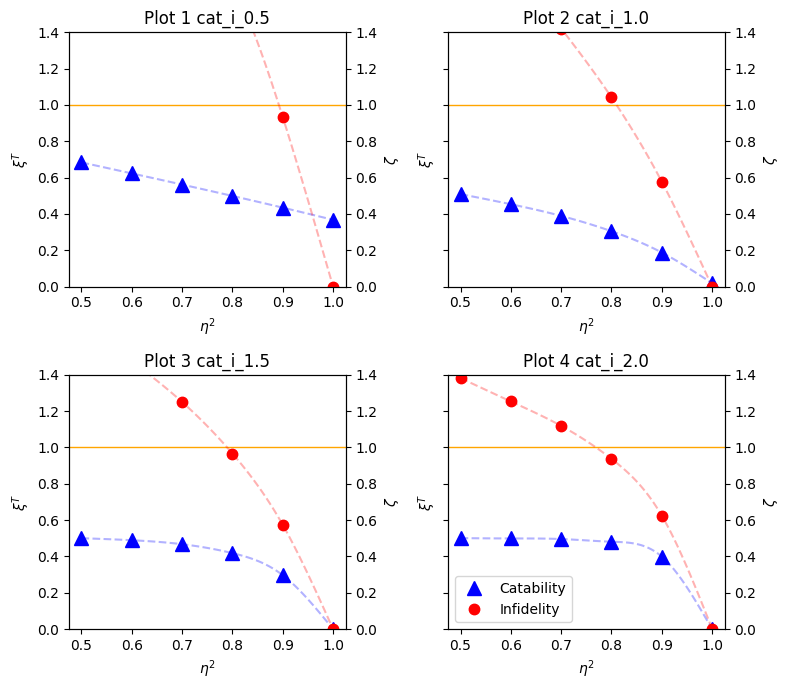

In [3]:
import matplotlib.pyplot as plt
import scipy.interpolate as si

def load_dataset (label):
    return np.load(f'results/transposition/{label}.npy')

tspace = np.load('results/transposition/tspace.npy')

labels = [
    f'cat_i_0.5',f'cat_i_1.0',
    f'cat_i_1.5',f'cat_i_2.0']

fig, axes = plt.subplots(2, 2, figsize = (8, 7),sharey = True)
fig.subplots_adjust(hspace = 0.4, wspace = 0.3)

for i, label in enumerate(labels):

    row = i // 2
    col = i  % 2

    dataset = load_dataset(label)

    x = tspace
    y1 = dataset[:, 0]
    y2 = dataset[:, 1]

    cs1 = si.CubicSpline(x, y1, bc_type = 'natural')
    x_fine1 = np.linspace(min(x), max(x), 100)
    y_fine1 = cs1(x_fine1)

    cs2 = si.CubicSpline(x, y2, bc_type = 'natural')
    x_fine2 = np.linspace(min(x), max(x), 100)
    y_fine2 = cs2(x_fine2)


    axes[row, col].plot(x, y1, "^b", markersize = 10,label =r'Catability')
    axes[row, col].plot(x_fine1, y_fine1, "--b", alpha = 0.3)
    axes[row, col].axhline(y = 1, color="orange", linewidth = 1)
    axes[row, col].set_xlabel(r"$\eta^2$")
    axes[row, col].set_title(f"Plot {i+1} {label}")
    axes[row, col].set_ylabel(r"$\xi^T$")
    # axes[row,col].set_ylim(0.0,0.1)
    axes[row, col].set_ylim(0.00, 1.4)

    ax2 = axes[row,col].twinx()
    ax2.plot(x, y2, ".r", markersize = 15,label = r'Infidelity')
    ax2.plot(x_fine2, y_fine2, "--r", alpha = 0.3)
    ax2.set_ylabel(r"$\zeta$")
    ax2.set_ylim(0.00, 1.4)
handles1, labels1 = axes[0,0].get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
axes[1,1].legend(handles1 + handles2, labels1 + labels2, loc='lower left')
plt.tight_layout()
plt.show()
fig.savefig('figs/transposition.svg')